In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
def printPlot(df):

    window = 252
    
    df['rolling_mean'] = df['Close'].rolling(window).mean()
    df['rolling_std'] = df['Close'].rolling(window).std()
    
    # 그래프
    plt.figure(figsize=(16, 8))
    
    sns.set_style('darkgrid')
    
    plt.plot(
        df.index,
        df['Close'],
        label='Close',
        linewidth=2
    )
    
    plt.plot(
        df.index,
        df['rolling_mean'],
        label='rolling_mean',
        linewidth=2
    )
    
    plt.plot(
        df.index,
        df['rolling_std'],
        label='rolling_std',
        linewidth=2
    )
    
    plt.title('Gold Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    
    plt.show()

### 데이터 불러오기(금시세 2000~2011년도)

In [8]:
file_path = "../Data-collection/dailyStock"
target = "GC=F"
file_path = f"{file_path}/{target}.csv"

gold_df = pd.read_csv(file_path, encoding="utf-8")
gold_df['Date'] = pd.to_datetime(gold_df['Date'])
gold_df = gold_df.set_index("Date")

gold_df = gold_df.loc["2001-01-01":"2011-12-31"]

### 이동 평균, 표준편차 시각화

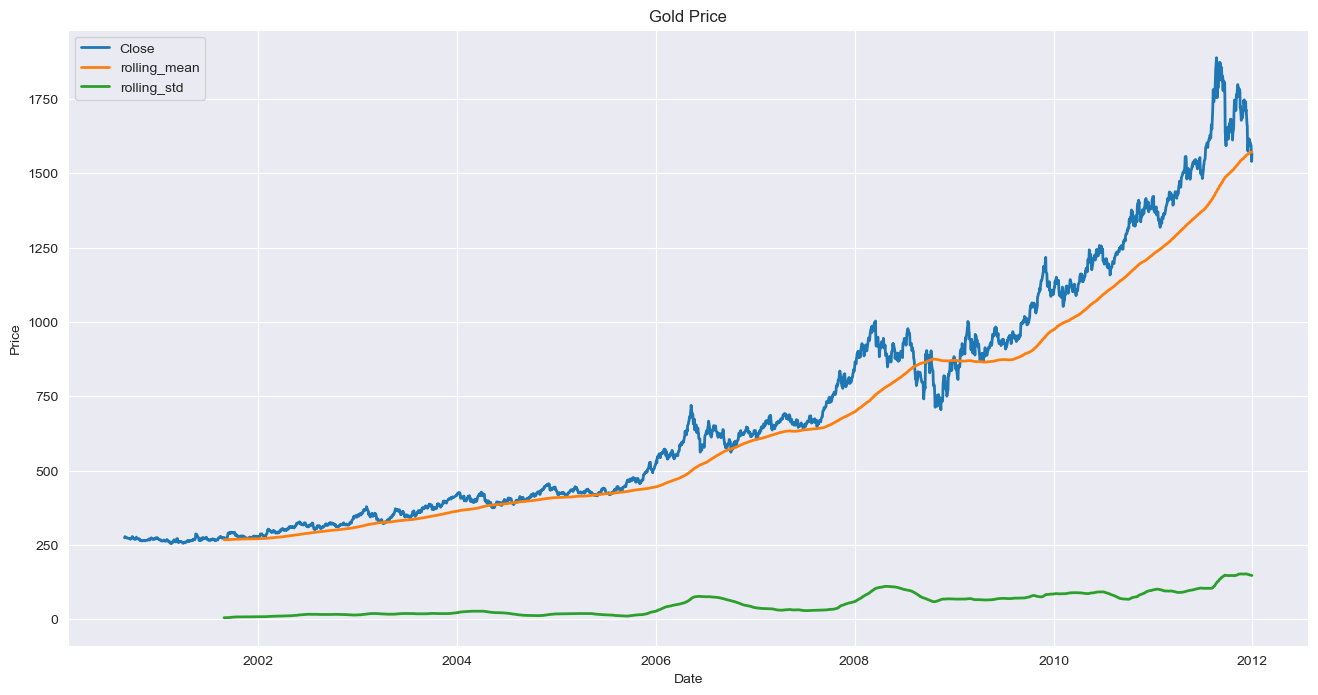

In [64]:
printPlot(gold_Df)

### 시계열 분해 검사(관측값, 추세, 계절성, 잔차 시각화)

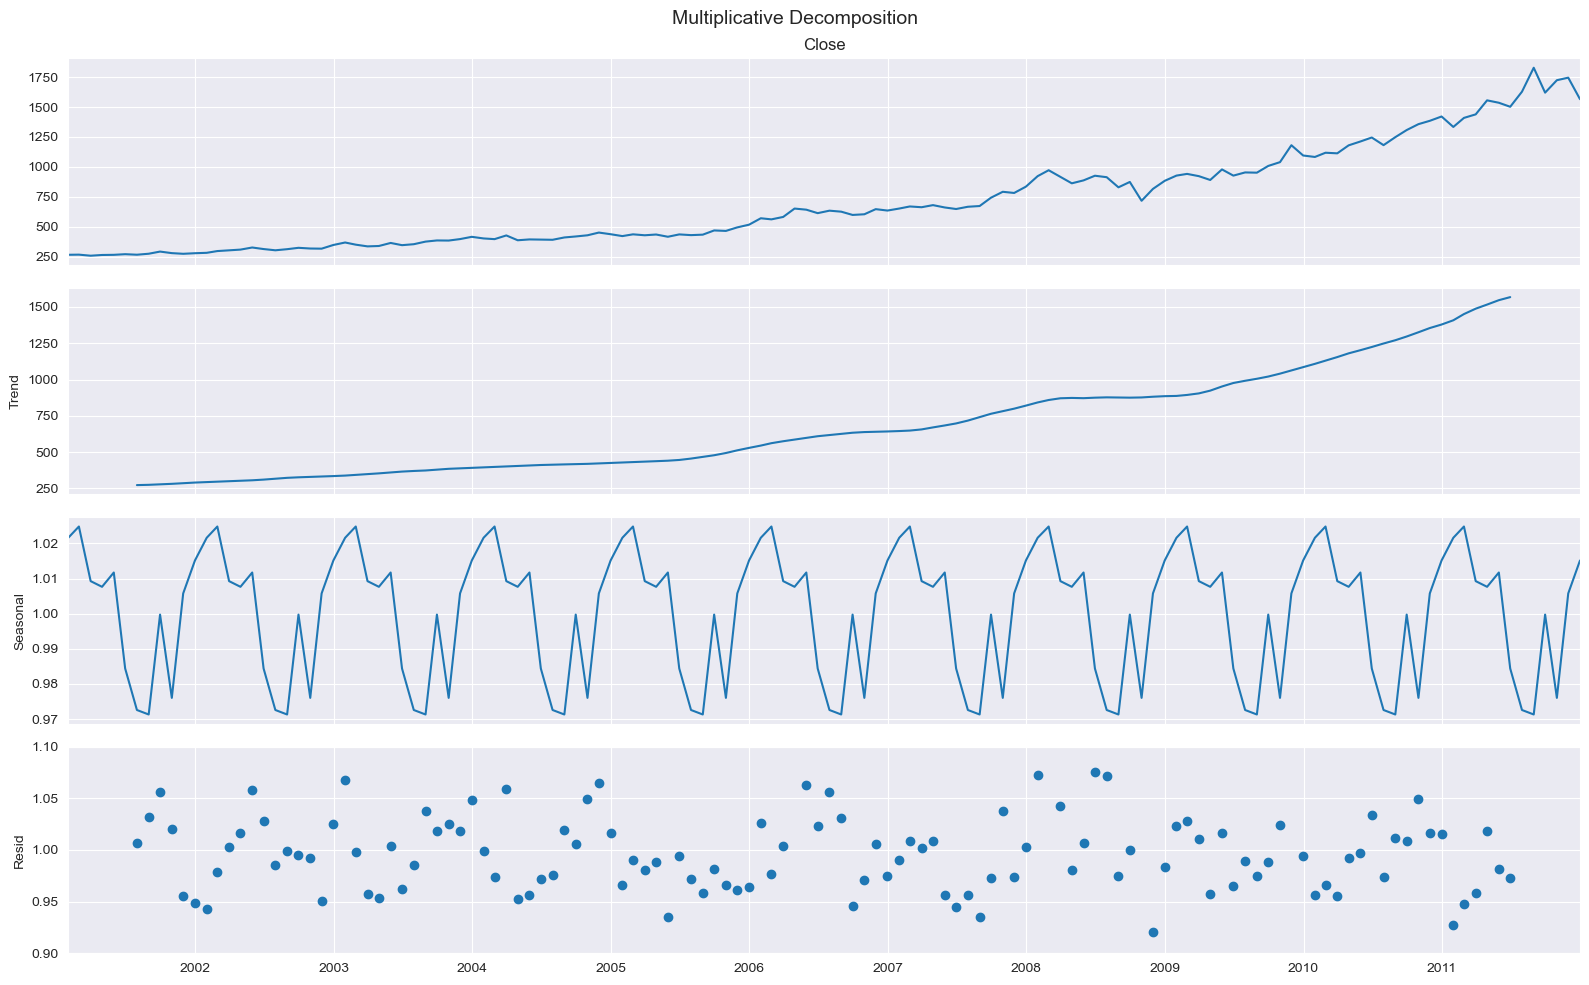

In [67]:
gold_monthly = gold_df['Close'].resample('ME').last()

decomposition_results = seasonal_decompose(
    gold_monthly,
    model='multiplicative',
    period=12
)

fig = decomposition_results.plot()

# Residual Y축 범위 설정
fig.axes[3].set_ylim(0.90, 1.10)

fig.suptitle('Multiplicative Decomposition', fontsize=14)
fig.set_size_inches(16, 10)

plt.tight_layout()
plt.show()